## **미용업 데이터**

### **1. 미용실 데이터 전처리**

- 일단 가격 기준의 long 데이터를 만든다. 

- 메뉴를 '커트'와 '펌'의 '메뉴 타입'으로 구분하여 평균을 구할 것임. 이때 '손톱 케이' 등의 기타 메뉴의 경우에는 그냥 없앤다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/광진구 미용 최종.csv")
df.head()

,상호,업종,주소,메뉴
0,플랜에이치 건대역1호점,미용실,서울 광진구 아차산로30길 8 2층,"첫방문 남성컷(N예약+N페이)(15,400원), 첫방문 여성컷(N예약+N페이)(17..."
1,설렘 미용실,미용실,서울 광진구 능동로11길 9 설렘,"남&여 컷트(22,000원), 펌(88,000원), 일반염색(55,000원), 일반..."
2,헤어더뷰 건대점,미용실,서울 광진구 능동로 123 2층,"첫방문 커트(17,500원), 맨즈 베이직 펌(63,000원), 우먼즈 디지털/셋팅..."
3,준오헤어 구의역점,미용실,서울 광진구 아차산로 355 301호,"디자인컷(35,000원), 다운펌(40,000원), 앞 머리펌(50,000원), 일..."
4,더 디얼스 롯데백화점 건대스타시티점,미용실,서울 광진구 능동로 92 롯데백화점 스타시티몰 스타존 3층 301호,"포인트 앞머리컷(1,000원), 남성컷+성형다운펌(52,000원), 첫방문50% 맨..."


In [3]:
df.drop(columns=['주소','업종'], inplace=True)

In [4]:
df.isnull().sum()

상호      0
메뉴    131
dtype: int64

In [5]:
df.dropna()
split_menu = df['메뉴'].str.split(',')

df['정보1'] = split_menu.str[0] + ',' + split_menu.str[1]
df['정보2'] = split_menu.str[2] + ',' + split_menu.str[3]

df.head()

,상호,메뉴,정보1,정보2
0,플랜에이치 건대역1호점,"첫방문 남성컷(N예약+N페이)(15,400원), 첫방문 여성컷(N예약+N페이)(17...","첫방문 남성컷(N예약+N페이)(15,400원)","첫방문 여성컷(N예약+N페이)(17,500원)"
1,설렘 미용실,"남&여 컷트(22,000원), 펌(88,000원), 일반염색(55,000원), 일반...","남&여 컷트(22,000원)","펌(88,000원)"
2,헤어더뷰 건대점,"첫방문 커트(17,500원), 맨즈 베이직 펌(63,000원), 우먼즈 디지털/셋팅...","첫방문 커트(17,500원)","맨즈 베이직 펌(63,000원)"
3,준오헤어 구의역점,"디자인컷(35,000원), 다운펌(40,000원), 앞 머리펌(50,000원), 일...","디자인컷(35,000원)","다운펌(40,000원)"
4,더 디얼스 롯데백화점 건대스타시티점,"포인트 앞머리컷(1,000원), 남성컷+성형다운펌(52,000원), 첫방문50% 맨...","포인트 앞머리컷(1,000원)","남성컷+성형다운펌(52,000원)"


In [6]:
df['메뉴1'] = df['정보1'].str.extract(r'^(.*)\([^()]*\)$')[0]
df['가격1'] = df['정보1'].str.extract(r'\(([\d,]+)원\)')[0].str.replace(',', '')
df['메뉴2'] = df['정보2'].str.extract(r'^(.*)\([^()]*\)$')[0]
df['가격2'] = df['정보2'].str.extract(r'\(([\d,]+)원\)')[0].str.replace(',', '')

df.drop(columns=['정보1','정보2','메뉴'], inplace=True)
df = df.dropna()
df.head()

,상호,메뉴1,가격1,메뉴2,가격2
0,플랜에이치 건대역1호점,첫방문 남성컷(N예약+N페이),15400,첫방문 여성컷(N예약+N페이),17500
1,설렘 미용실,남&여 컷트,22000,펌,88000
2,헤어더뷰 건대점,첫방문 커트,17500,맨즈 베이직 펌,63000
3,준오헤어 구의역점,디자인컷,35000,다운펌,40000
4,더 디얼스 롯데백화점 건대스타시티점,포인트 앞머리컷,1000,남성컷+성형다운펌,52000


In [7]:
df['가격1'] = pd.to_numeric(df['가격1'], errors='coerce')
df['가격2'] = pd.to_numeric(df['가격2'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 157 entries, 0 to 287
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상호      157 non-null    object
 1   메뉴1     157 non-null    object
 2   가격1     157 non-null    int64 
 3   메뉴2     157 non-null    object
 4   가격2     157 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 7.4+ KB


In [8]:
df1 = df[['메뉴1','가격1','상호']].copy()
df1.columns = ['메뉴','가격','가게명']

df2 = df[['메뉴2','가격2','상호']].copy()
df2.columns = ['메뉴','가격','가게명']

df_long = pd.concat([df1,df2], ignore_index=True)

df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      314 non-null    object
 1   가격      314 non-null    int64 
 2   가게명     314 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.5+ KB


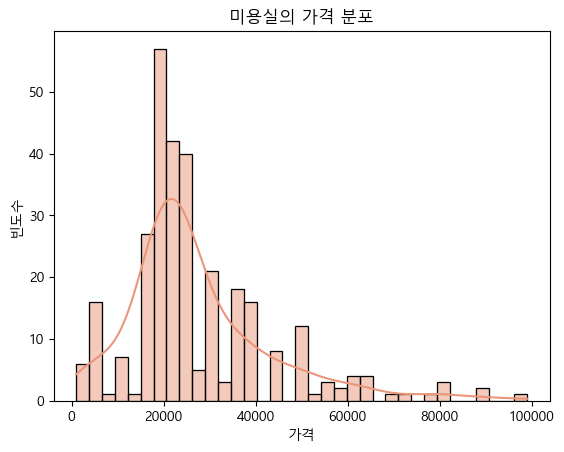

In [9]:
sns.histplot(data= df_long[df_long['가격']< 100000], x='가격', bins=35, kde=True, color='darksalmon')
plt.title('미용실의 가격 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [10]:
df_long.head()

,메뉴,가격,가게명
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점
1,남&여 컷트,22000,설렘 미용실
2,첫방문 커트,17500,헤어더뷰 건대점
3,디자인컷,35000,준오헤어 구의역점
4,포인트 앞머리컷,1000,더 디얼스 롯데백화점 건대스타시티점


In [11]:
cut = ['커트','컷','컷트','CUT']
perm = ['펌']

def get_menu_type(menu):
    is_cut = any(word in menu for word in cut)
    is_perm = any(word in menu for word in perm)

    if is_cut and is_perm:
        return '펌'
    elif is_cut:
        return '커트'
    elif is_perm:
        return '펌'
    else:
        return None  # 아무것도 해당 안 될 때

df_long['메뉴 타입'] = df_long['메뉴'].apply(get_menu_type)

df_long.head()

,메뉴,가격,가게명,메뉴 타입
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트
1,남&여 컷트,22000,설렘 미용실,커트
2,첫방문 커트,17500,헤어더뷰 건대점,커트
3,디자인컷,35000,준오헤어 구의역점,커트
4,포인트 앞머리컷,1000,더 디얼스 롯데백화점 건대스타시티점,커트


In [12]:
df_long.dropna(inplace=True)
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 228 entries, 0 to 312
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      228 non-null    object
 1   가격      228 non-null    int64 
 2   가게명     228 non-null    object
 3   메뉴 타입   228 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.9+ KB


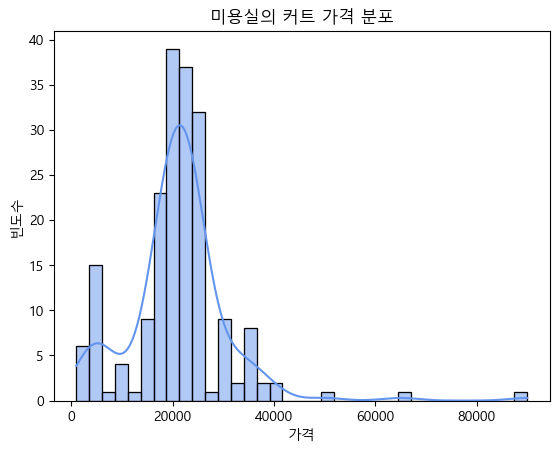

In [13]:
sns.histplot(data= df_long[df_long['메뉴 타입']=='커트'], 
             x='가격', bins=35, kde=True, color='cornflowerblue')
plt.title('미용실의 커트 가격 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

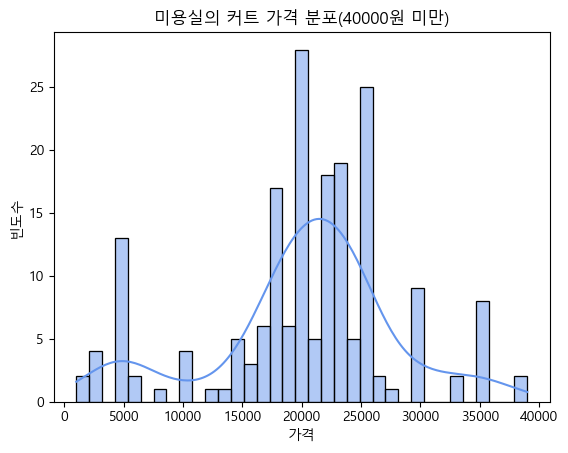

In [14]:
sns.histplot(data= df_long[(df_long['메뉴 타입']=='커트') & (df_long['가격']< 40000)], 
             x='가격', bins=35, kde=True, color='cornflowerblue')
plt.title('미용실의 커트 가격 분포(40000원 미만)')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [15]:
# '커트'의 경우 하한 Outlier를 9000원 이하로 정의하고 상한 Outlier는 40000원으로 정의한다.

df_long[df_long['메뉴 타입']=='커트'].sort_values(by='가격').head()

,메뉴,가격,가게명,메뉴 타입
4,포인트 앞머리컷,1000,더 디얼스 롯데백화점 건대스타시티점,커트
138,앞머리컷(초.중.고),1000,살롱제이,커트
37,앞머리컷,3000,라청담미용실,커트
55,앞머리컷,3000,제오헤어 군자점,커트
84,앞머리컷,3000,도아살롱 군자점,커트


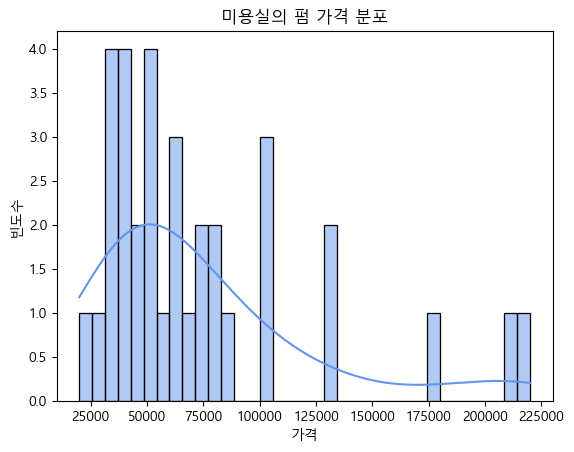

In [16]:
sns.histplot(data= df_long[df_long['메뉴 타입']=='펌'], 
             x='가격', bins=35, kde=True, color='cornflowerblue')
plt.title('미용실의 펌 가격 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

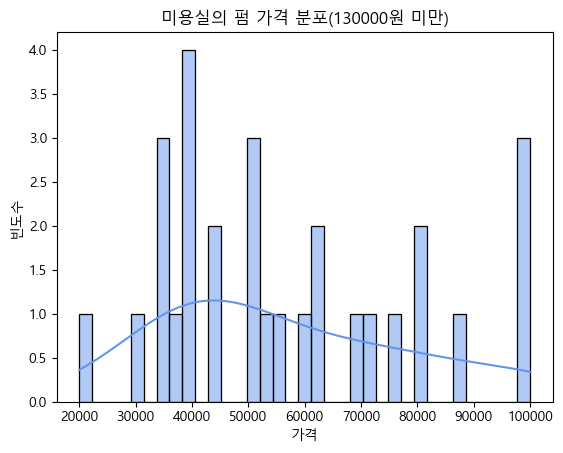

In [17]:
# '펌'의 경우 위쪽 Outliers만 제거하여 130,000원 미만 데이터만 남긴다. 

sns.histplot(data= df_long[(df_long['메뉴 타입']=='펌') & (df_long['가격']< 130000)], 
             x='가격', bins=35, kde=True, color='cornflowerblue')
plt.title('미용실의 펌 가격 분포(130000원 미만)')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [18]:
# final data

df_long = df_long[
    ((df_long['메뉴 타입'] == '커트') & (df_long['가격'].between(9000, 40000))) |
    ((df_long['메뉴 타입'] == '펌') & (df_long['가격'] < 130000))
]


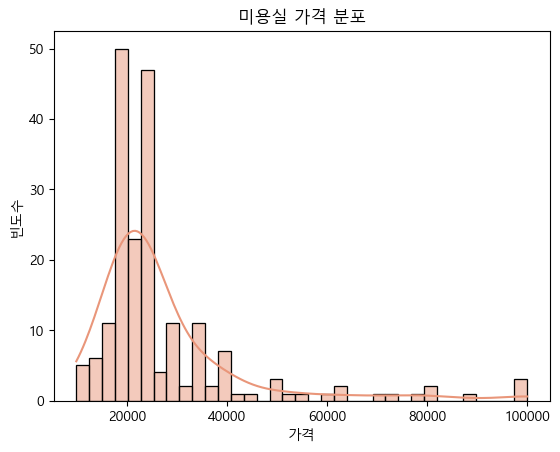

In [19]:
sns.histplot(data= df_long, 
             x='가격', bins=35, kde=True, color='darksalmon')
plt.title('미용실 가격 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

### **2. '가격' 점수 부여하기**

'음식점' 업소와 동일한 기준 적용하기에는 어려움이 있다.

따라서 '미용실' 업소의 경우 가격점수를 100점 만점으로 하고,

위생 데이터의 경우 가산점을 부여하는 것이 아닌 '위생처분 업소'에 대한 큰 감점을 부여하는 것으로 한다. 


In [20]:
df_long['평균가격'] = df_long.groupby('메뉴 타입')['가격'].transform('mean').round(2)
df_long.head()

,메뉴,가격,가게명,메뉴 타입,평균가격
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트,22527.22
1,남&여 컷트,22000,설렘 미용실,커트,22527.22
2,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22
3,디자인컷,35000,준오헤어 구의역점,커트,22527.22
6,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22


In [21]:
def 점수계산(row):
    가격 = row['가격']
    평균 = row['평균가격']
    
    if 가격 <= 평균:
        감점비율 = (평균- 가격) / 평균
        score = 100 * (감점비율)
    else:
        score = 0
    
    return max(score, 0)  # 점수는 최소 0

df_long['가격점수'] = df_long.apply(점수계산, axis=1)
df_long.head()

,메뉴,가격,가게명,메뉴 타입,평균가격,가격점수
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트,22527.22,31.638258
1,남&여 컷트,22000,설렘 미용실,커트,22527.22,2.340369
2,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22,22.316202
3,디자인컷,35000,준오헤어 구의역점,커트,22527.22,0.000000
6,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22,24.535739


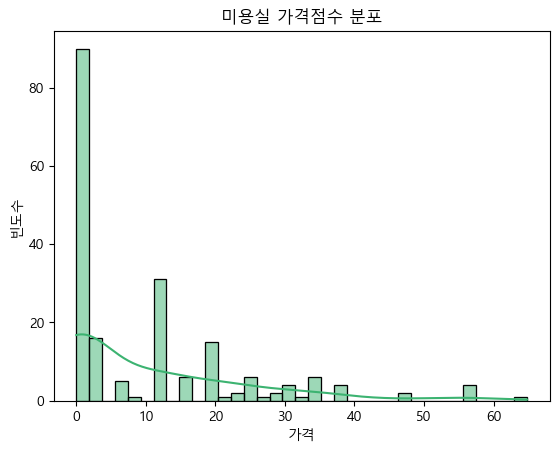

In [22]:
sns.histplot(data= df_long, 
             x='가격점수', bins=35, kde=True, color='mediumseagreen')
plt.title('미용실 가격점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

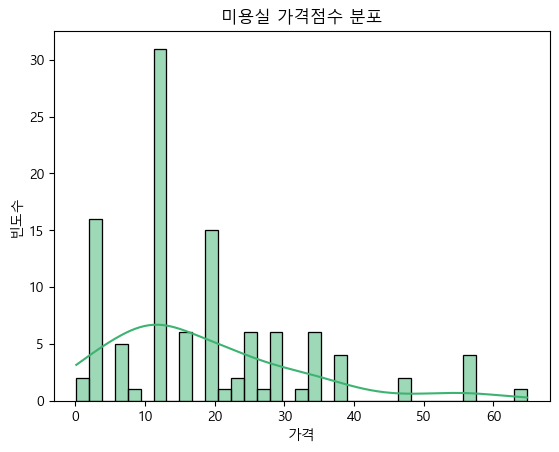

In [23]:
sns.histplot(data= df_long[df_long['가격점수']>0], 
             x='가격점수', bins=35, kde=True, color='mediumseagreen')
plt.title('미용실 가격점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

### **3. 위생 데이터 추가하기**

서울시에서 제공하는 위생 데이터는 기본적으로 음식점 위주이다.

미용업 관련해서 확보할 수 있는 데이터는 '위생처분 업소'관련 데이터 뿐이기 때문에,

'위생처분 업소'에는 많은 패널티(-40점) 을 부여한다.

In [24]:
df_bad = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/광진구 공중위생업소 행정처분현황.csv", encoding='cp949')
df_bad.head()

,시군구코드,처분일자,교부번호,업종명,업태명,업소명,소재지도로명,소재지지번,지도점검일자,행정처분상태,처분명,법적근거,위반일자,위반내용,처분내용,처분기간,영업장면적(㎡)
0,3040000,20091214,002,숙박업(일반),여관업,대원장여관,NaN,서울특별시 광진구 화양동 115번지 8호,20090721,처분확정,과징금부과,공중위생관리법 제11조,20090721,청소년 이성 혼숙행위(광진경찰서장으로부터 2009.7.21경 통보 받음),과징금부과,NaN,52.82
1,3040000,20101210,002,숙박업(일반),여관업,대원장여관,NaN,서울특별시 광진구 화양동 115번지 8호,20100907,처분확정,영업정지,공중위생관리법 제11조,20100907,숙박자에게 성매매알선등 행위,영업정지,NaN,52.82
2,3040000,20041105,4,숙박업(일반),여관업,동궁여관,NaN,서울특별시 광진구 자양동 236번지 64호,20040619,처분확정,"영업정지 2월을 갈음한 과징금 1,800,000원","공중위생관리법 제11조,제12조",20040619,청소년 이성혼숙 장소제공,"영업정지 2월을 갈음한 과징금 1,800,000원",0.0,68.00
3,3040000,20040427,8,숙박업(일반),여관업,도원여관,NaN,서울특별시 광진구 중곡동 196번지 11호,20040315,처분확정,"과징금1,800,000원","공중위생관리법 제11조, 제12조",20040315,청소년 남녀 혼숙위반,"과징금1,800,000원",0.0,50.00
4,3040000,20080905,008,숙박업(일반),여관업,도원여관,NaN,서울특별시 광진구 중곡동 196번지 11호,20080812,처분확정,영업소폐쇄,공중위생관리법제3조,20080812,폐업신고 없이 시설물멸실,영업소폐쇄,NaN,50.00


In [25]:
df_bad.columns

Index(['시군구코드', '처분일자', '교부번호', '업종명', '업태명', '업소명', '소재지도로명', '소재지지번',
       '지도점검일자', '행정처분상태', '처분명', '법적근거', '위반일자', '위반내용', '처분내용', '처분기간',
       '영업장면적(㎡)'],
      dtype='object')

In [26]:
drop_cols = ['시군구코드', '처분일자', '교부번호','소재지도로명', '소재지지번',
             '지도점검일자', '행정처분상태', '처분명', '법적근거', '위반일자', '위반내용', '처분내용', '처분기간',
             '영업장면적(㎡)']
df_bad.drop(columns = drop_cols, inplace=True)
df_bad.head()

,업종명,업태명,업소명
0,숙박업(일반),여관업,대원장여관
1,숙박업(일반),여관업,대원장여관
2,숙박업(일반),여관업,동궁여관
3,숙박업(일반),여관업,도원여관
4,숙박업(일반),여관업,도원여관


In [27]:
df_bad.rename(columns={'업소명': '가게명'}, inplace=True)
df_long['위생점수'] = 0
df_bad.head()

,업종명,업태명,가게명
0,숙박업(일반),여관업,대원장여관
1,숙박업(일반),여관업,대원장여관
2,숙박업(일반),여관업,동궁여관
3,숙박업(일반),여관업,도원여관
4,숙박업(일반),여관업,도원여관


In [28]:
common_names = set(df_long['가게명']) & set(df_bad['가게명'])

print("겹치는 가게명 수:", len(common_names))
print("겹치는 가게명 목록:", common_names)


겹치는 가게명 수: 2
겹치는 가게명 목록: {'굿보이즈 바버샵', '유앤헤어'}


In [29]:
df_long.loc[df_long['가게명'].isin(df_bad['가게명']), '위생점수'] = -40
df_long.head()

,메뉴,가격,가게명,메뉴 타입,평균가격,가격점수,위생점수
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트,22527.22,31.638258,0
1,남&여 컷트,22000,설렘 미용실,커트,22527.22,2.340369,0
2,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22,22.316202,0
3,디자인컷,35000,준오헤어 구의역점,커트,22527.22,0.000000,0
6,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22,24.535739,0


In [30]:
df_long['총 점수'] = df_long['가격점수']+df_long['위생점수']
df_long.head()

,메뉴,가격,가게명,메뉴 타입,평균가격,가격점수,위생점수,총 점수
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트,22527.22,31.638258,0,31.638258
1,남&여 컷트,22000,설렘 미용실,커트,22527.22,2.340369,0,2.340369
2,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22,22.316202,0,22.316202
3,디자인컷,35000,준오헤어 구의역점,커트,22527.22,0.000000,0,0.000000
6,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22,24.535739,0,24.535739


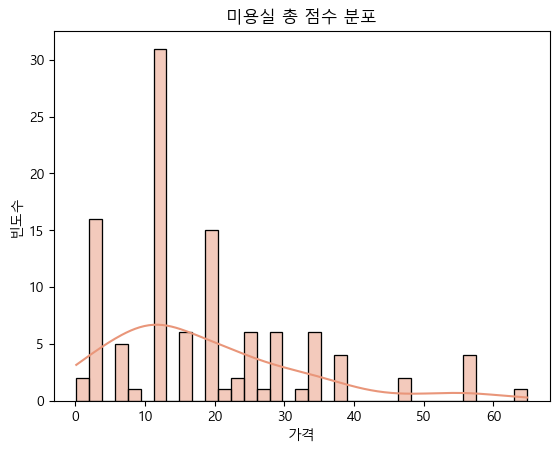

In [31]:
sns.histplot(data= df_long[df_long['총 점수']>0], 
             x='총 점수', bins=35, kde=True, color='darksalmon')
plt.title('미용실 총 점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [32]:
# final data

df_final = df_long[df_long['총 점수']>0]
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110 entries, 0 to 312
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   메뉴      110 non-null    object 
 1   가격      110 non-null    int64  
 2   가게명     110 non-null    object 
 3   메뉴 타입   110 non-null    object 
 4   평균가격    110 non-null    float64
 5   가격점수    110 non-null    float64
 6   위생점수    110 non-null    int64  
 7   총 점수    110 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 7.7+ KB


In [ ]:
# df_final.to_csv('광진구 미용실 총 점수.csv', index=False, encoding='utf-8-sig')

In [33]:
duplicate_names = df_final[df_final['가게명'].duplicated()]
has_duplicates = df_final['가게명'].duplicated().any()

print("중복 여부:", has_duplicates)
print("중복된 가게명들:")
print(duplicate_names)

중복 여부: True
중복된 가게명들:
                     메뉴     가격             가게명 메뉴 타입      평균가격       가격점수  \
157    첫방문 여성컷(N예약+N페이)  17500    플랜에이치 건대역1호점    커트  22527.22  22.316202   
163                남성 컷  19000   박준뷰티랩 뚝섬유원지역점    커트  22527.22  15.657591   
166        [펌이벤트] 다운펌+컷  35000            건대지금     펌  56886.21  38.473665   
168                남성 컷  20000       제오헤어 강변역점    커트  22527.22  11.218517   
171     남성 커트(직급별 차등요금)  22000        헤어웨이 광장점    커트  22527.22   2.340369   
173     커트다운펌(N페이결제시할인)  29700        디탐헤어 건대점     펌  56886.21  47.790510   
180         (신규)디자인컷-여성  18000        에이컨셉 구의점    커트  22527.22  20.096665   
182                 여성컷  22000      헤어온드유 군자역점    커트  22527.22   2.340369   
184                롯드 펌  40000  헤어웨이 스페이스 세종대점     펌  56886.21  29.684189   
185   남성 커트 (직급별 차등 요금)  22000      헤어웨이 구의강변점    커트  22527.22   2.340369   
192                남성 컷  19000    박공헤어 화양세종하우스    커트  22527.22  15.657591   
209      여성컷 (직급별 차등요금)  20000     봄베리 광진아차산역점    커트  

### **4. 지역화폐 데이터 결합하기**

In [34]:
df_zero = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/지역화폐(미용).csv")
df_zero.head()

,가게명,지역화폐,메뉴,가격,메뉴 타입,평균가격,가격점수,위생점수,총 점수
0,플랜에이치 건대역1호점,X,첫방문 남성컷(N예약+N페이),15400,커트,22527.22,31.638258,0,31.638258
1,설렘 미용실,X,남&여 컷트,22000,커트,22527.22,2.340369,0,2.340369
2,헤어더뷰 건대점,O,첫방문 커트,17500,커트,22527.22,22.316202,0,22.316202
3,박준뷰티랩 뚝섬유원지역점,O,학생 컷,17000,커트,22527.22,24.535739,0,24.535739
4,건대지금,X,첫방문커트,18000,커트,22527.22,20.096665,0,20.096665


In [36]:
df_zero.isna().sum()

가게명      0
지역화폐     0
메뉴       0
가격       0
메뉴 타입    0
평균가격     0
가격점수     0
위생점수     0
총 점수     0
dtype: int64

In [35]:
df_final.head()

,메뉴,가격,가게명,메뉴 타입,평균가격,가격점수,위생점수,총 점수
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트,22527.22,31.638258,0,31.638258
1,남&여 컷트,22000,설렘 미용실,커트,22527.22,2.340369,0,2.340369
2,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22,22.316202,0,22.316202
6,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22,24.535739,0,24.535739
9,첫방문커트,18000,건대지금,커트,22527.22,20.096665,0,20.096665


In [37]:
df_long = df_long.merge(df_zero[['가게명', '지역화폐']], on='가게명', how='left')
df_long.head()

,메뉴,가격,가게명,메뉴 타입,평균가격,가격점수,위생점수,총 점수,지역화폐
0,첫방문 남성컷(N예약+N페이),15400,플랜에이치 건대역1호점,커트,22527.22,31.638258,0,31.638258,X
1,남&여 컷트,22000,설렘 미용실,커트,22527.22,2.340369,0,2.340369,X
2,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22,22.316202,0,22.316202,O
3,디자인컷,35000,준오헤어 구의역점,커트,22527.22,0.000000,0,0.000000,X
4,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22,24.535739,0,24.535739,O


In [39]:
df_filtered = df_long[df_long['지역화폐']=='O']
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57 entries, 2 to 197
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   메뉴      57 non-null     object 
 1   가격      57 non-null     int64  
 2   가게명     57 non-null     object 
 3   메뉴 타입   57 non-null     object 
 4   평균가격    57 non-null     float64
 5   가격점수    57 non-null     float64
 6   위생점수    57 non-null     int64  
 7   총 점수    57 non-null     float64
 8   지역화폐    57 non-null     object 
dtypes: float64(3), int64(2), object(4)
memory usage: 4.5+ KB


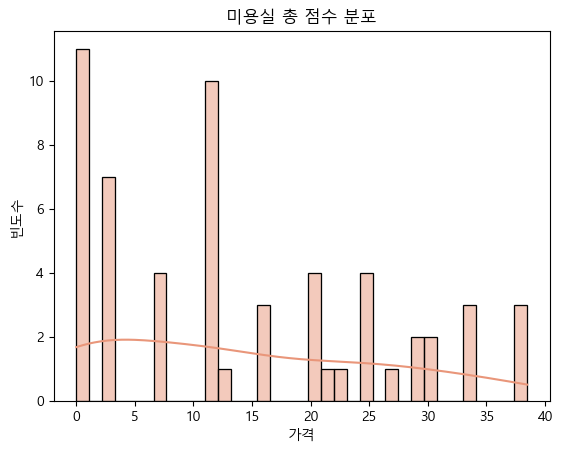

In [40]:
sns.histplot(data= df_filtered, 
             x='총 점수', bins=35, kde=True, color='darksalmon')
plt.title('미용실 총 점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [41]:
# final data

df_filtered.to_csv('광진구 미용업 점수 최종.csv',encoding='utf-8-sig', index=False)